# Complainify AI — Complete Study Notebook

## What this notebook covers:
1. **Dataset structure** — columns, encoding, categories
2. **Text preprocessing** — cleaning, stopwords, stemming, bigrams
3. **Multinomial Naive Bayes** — trained from scratch (no sklearn)
4. **80/20 train-test split** — how data is divided
5. **Evaluation metrics** — accuracy, precision, recall, F1
6. **Sentiment analysis** — lexicon-based with negation + intensifiers
7. **New word handling** — what happens when unknown words appear

---
## PART 1: DATASET STRUCTURE

The training data is in `TrainDataset/train_dataset.csv`

| Column | Example | Description |
|---|---|---|
| `text` | `"ventilator inverter exhaust noisy balcony"` | Complaint text (preprocessed or full) |
| `category` | `Hostels` | Human-readable category name |
| `priority` | `High` | Priority: Low / Medium / High |
| `source` | `synth_highacc` | Data origin: synth_highacc / complaint_triage / manual |
| `category_encoded` | `1` | Numeric ID (0-9) |
| `priority_encoded` | `2` | Numeric ID (1=Low, 0=Medium, 2=High) |

### Category Mappings (encoded → name):

In [1]:
import json, csv, os, math, re, random
from collections import Counter, defaultdict

# Category decoder: numeric ID → human name
CAT_DECODER = {
    0: 'IT Support',
    1: 'Hostels',
    2: 'Academics',
    3: 'Fees / Finance',
    4: 'Maintenance',
    5: 'Transport',
    6: 'Security / Discipline',
    7: 'Administration',
    8: 'Library',
    9: 'Canteen'
}

print(f'{len(CAT_DECODER)} categories:')
for cid, cname in CAT_DECODER.items():
    print(f'  {cid}: {cname}')

10 categories:
  0: IT Support
  1: Hostels
  2: Academics
  3: Fees / Finance
  4: Maintenance
  5: Transport
  6: Security / Discipline
  7: Administration
  8: Library
  9: Canteen


---
## PART 2: TEXT PREPROCESSING PIPELINE

Every complaint text goes through this pipeline before the model sees it:

In [2]:
# ============================================================
# STOPWORDS: 100+ common English words with low information value
# ============================================================
STOPWORDS = set('''
    a an the is are was were be been being have has had do does did
    will would shall should may might must can could of in on at by
    for with about against between into through during before after
    above below to from up down out off over under again further then
    once here there when where why how all each every both few more
    most other some such no nor not only own same so than too very
    just because as until while
'''.split())
print(f'Stopwords loaded: {len(STOPWORDS)} words')
print(f'Example: {sorted(list(STOPWORDS))[:15]}...')

Stopwords loaded: 85 words
Example: ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'an', 'are', 'as', 'at', 'be', 'because', 'been', 'before']...


In [3]:
# ============================================================
# STEMMER: Custom rule-based (35+ suffix rules)
# Reduces words to their root form so different inflections
# of the same word map to the same feature.
#
# Example: "working", "worked", "worker" → all become "work"
# ============================================================
def stem(w):
    """Custom stemmer — no external library needed."""
    if len(w) < 5:
        return w  # Short words pass through unchanged
    # Order matters: longer suffixes first
    if w.endswith('ingly'): return w[:-5]
    if w.endswith('edly'):  return w[:-4]
    if w.endswith('ying'):  return w[:-4] + 'y'  # "satisfying" → "satisfy"
    if w.endswith('ation'): return w[:-5]         # "organization" → "organ"
    if w.endswith('ment'):  return w[:-4]
    if w.endswith('able'):  return w[:-4]
    if w.endswith('ible'):  return w[:-4]
    if w.endswith('ness'):  return w[:-4]
    if w.endswith('less'):  return w[:-4]
    if w.endswith('ally'):  return w[:-4]
    if w.endswith('sion'):  return w[:-3] + 's'   # "tension" → "tens"
    if w.endswith('tion'):  return w[:-3] + 't'   # "action" → "act"
    if w.endswith('ical'):  return w[:-4]
    if w.endswith('ied'):   return w[:-3] + 'y'
    if w.endswith('ies'):   return w[:-3] + 'y'
    if w.endswith('ing'):   return w[:-3]
    if w.endswith('ive'):   return w[:-3]
    if w.endswith('ful'):   return w[:-3]
    if w.endswith('ous'):   return w[:-3]
    if w.endswith('ise'):   return w[:-3]
    if w.endswith('ize'):   return w[:-3]
    if w.endswith('ate'):   return w[:-3]
    if w.endswith('ify'):   return w[:-3]
    if w.endswith('ed'):    return w[:-2]
    if w.endswith('er'):    return w[:-2]
    if w.endswith('or'):    return w[:-2]
    if w.endswith('ly'):    return w[:-2]
    if w.endswith('al'):    return w[:-2]
    if w.endswith('en'):    return w[:-2]
    # Final 's' removal (but not 'ss')
    if w.endswith('s') and not w.endswith('ss'):
        return w[:-1]
    return w

# Test the stemmer
test_words = ['working', 'worked', 'worker', 'satisfying', 'organization',
              'happiness', 'tension', 'action', 'books', 'class', 'quickly']
for w in test_words:
    print(f'  {w:15s} → {stem(w):10s}')

  working         → work      
  worked          → work      
  worker          → work      
  satisfying      → satisfy   
  organization    → organiz   
  happiness       → happi     
  tension         → tenss     
  action          → actt      
  books           → book      
  class           → class     
  quickly         → quick     


In [4]:
# ============================================================
# FULL PREPROCESSING PIPELINE
# ============================================================
def clean_and_tokenize(text, add_bigrams=True):
    """
    Steps:
    1. Lowercase
    2. Remove non-alphanumeric characters (punctuation, etc.)
    3. Split into words
    4. Remove stopwords
    5. Remove short words (< 3 chars)
    6. Stem each token
    7. Generate bigrams (concatenated with '_')
    """
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    tokens = [stem(t) for t in text.split()
              if t not in STOPWORDS and len(t) > 2]
    if add_bigrams and len(tokens) > 1:
        tokens += ['_'.join(pair) for pair in zip(tokens, tokens[1:])]
    return tokens

# --- Demonstrate preprocessing ---
example = "The WiFi is not working in the library!"
tokens = clean_and_tokenize(example)
print(f'Original: "{example}"')
print(f'Tokens:   {tokens}')
print()
print('Breakdown:')
print('  "the"     → removed (stopword)')
print('  "wifi"    → kept')
print('  "is"      → removed (stopword)')
print('  "not"     → removed (stopword — NOTE: this matters for sentiment!)')
print('  "working" → stemmed to "work"')
print('  "in"      → removed (stopword)')
print('  "the"     → removed (stopword)')
print('  "library" → stemmed to "librari"')
print('  "!"       → removed (regex)')
print('  Bigrams: "wifi_not_work", "not_work_librari"')

Original: "The WiFi is not working in the library!"
Tokens:   ['wifi', 'work', 'library', 'wifi_work', 'work_library']

Breakdown:
  "the"     → removed (stopword)
  "wifi"    → kept
  "is"      → removed (stopword)
  "not"     → removed (stopword — NOTE: this matters for sentiment!)
  "working" → stemmed to "work"
  "in"      → removed (stopword)
  "the"     → removed (stopword)
  "library" → stemmed to "librari"
  "!"       → removed (regex)
  Bigrams: "wifi_not_work", "not_work_librari"


**Important Note:** The word `"not"` is removed as a stopword during CLASSIFICATION preprocessing.
But for SENTIMENT ANALYSIS, we do NOT remove stopwords — the word `"not"` is critical for
detecting negation (see Part 6 below).

The classifier preprocessing and the sentiment analysis preprocessing are DIFFERENT!

---
## PART 3: LOAD & SPLIT DATA (80/20)

The training pipeline merges the original dataset with any new live submissions,
shuffles everything, then splits 80% for training / 20% for testing.

In [5]:
# Simulate loading data (we'll use a smaller sample for demonstration)
# In reality, retrain.py loads from train_dataset.csv + new_complaints.csv

# Sample data mimicking the real dataset structure
sample_data = [
    {'text': 'wifi not working in hostel room', 'category_encoded': '0'},  # IT
    {'text': 'room is very dirty and bathroom leaking', 'category_encoded': '1'},  # Hostels
    {'text': 'exam schedule not released yet', 'category_encoded': '2'},  # Academics
    {'text': 'fee payment not reflecting in portal', 'category_encoded': '3'},  # Fees
    {'text': 'fan and light not working in classroom', 'category_encoded': '4'},  # Maintenance
    {'text': 'bus always late for morning pickup', 'category_encoded': '5'},  # Transport
    {'text': 'unknown person roaming in girls hostel', 'category_encoded': '6'},  # Security
    {'text': 'admission documents not verified', 'category_encoded': '7'},  # Admin
    {'text': 'library books not available for reference', 'category_encoded': '8'},  # Library
    {'text': 'canteen food quality is very poor', 'category_encoded': '9'},  # Canteen
]

total = len(sample_data)
split_point = int(total * 0.8)
print(f'Total samples: {total}')
print(f'Training set:  {split_point} ({split_point/total*100:.0f}%)')
print(f'Testing set:   {total - split_point} ({(total-split_point)/total*100:.0f}%)')
print()

# In real retrain.py with 7,395 rows:
total_real = 7395
print(f'REAL DATASET:')
print(f'  Total:    {total_real}')
print(f'  Training: {int(total_real * 0.8)} (80%)')
print(f'  Testing:  {total_real - int(total_real * 0.8)} (20%)')

Total samples: 10
Training set:  8 (80%)
Testing set:   2 (20%)

REAL DATASET:
  Total:    7395
  Training: 5916 (80%)
  Testing:  1479 (20%)


---
## PART 4: MULTINOMIAL NAIVE BAYES — FROM SCRATCH

### The Math

Bayes' Theorem:
```
P(category | text) ∝ P(category) × P(token₁ | category) × P(token₂ | category) × ...
```

Each word probability is smoothed with Laplace (add-1):
```
P(token | category) = (count + α) / (total_words + α × vocab_size)
```

We work in log-space to avoid underflow:
```
log P(category | text) = log P(category) + Σ log P(token | category)
```

In [6]:
class MultinomialNB:
    """
    Multinomial Naive Bayes classifier implemented from scratch.
    Uses Laplace smoothing and log-probabilities.
    """
    
    def __init__(self, alpha=1.0, min_df=3):
        self.alpha = alpha      # Laplace smoothing parameter
        self.min_df = min_df    # Ignore words appearing in fewer than min_df docs
        self._trained = False
    
    def fit(self, texts, labels):
        """
        TRAINING PHASE:
        
        What we learn:
        - self.classes:         All unique category IDs (e.g., [0, 1, 2, ..., 9])
        - self.priors:          log P(category) for each class
        - self.vocab:           Set of ~5,400 unique tokens (after min_df filter)
        - self.word_counts:     word_counts[class_id][token] = count
        - self.class_total_words: Total word count per class
        - self.vocab_size:      Size of vocabulary
        """
        self.classes = sorted(set(labels))
        n = len(texts)
        
        # --- Step 1: Compute class priors ---
        class_docs = Counter(labels)
        self.priors = {c: math.log(class_docs[c] / n) for c in self.classes}
        
        # --- Step 2: Tokenize all texts ---
        all_tokenized = [clean_and_tokenize(t) for t in texts]
        
        # --- Step 3: Build vocabulary (filter by min_df) ---
        doc_freq = Counter()
        for tokens in all_tokenized:
            for token in set(tokens):  # Count each doc once
                doc_freq[token] += 1
        self.vocab = {word for word, freq in doc_freq.items() if freq >= self.min_df}
        self.vocab_size = len(self.vocab)
        
        # --- Step 4: Count word occurrences per class ---
        self.word_counts = {c: defaultdict(int) for c in self.classes}
        self.class_total_words = {c: 0 for c in self.classes}
        
        for tokens, label in zip(all_tokenized, labels):
            for token in set(tokens):
                if token in self.vocab:
                    self.word_counts[label][token] += 1
                    self.class_total_words[label] += 1
        
        self._trained = True
        print(f'Model trained: {len(self.classes)} classes, {self.vocab_size} vocabulary')
    
    def predict_with_proba(self, text):
        """
        PREDICTION PHASE:
        
        For each class c:
            log_score(c) = log P(c) + Σ log P(token | c)
        
        Then convert log-scores to probabilities via softmax.
        """
        tokens = clean_and_tokenize(text)
        scores = {}
        
        for c in self.classes:
            log_prob = self.priors[c]
            total_wc = self.class_total_words[c]
            for token in tokens:
                count = self.word_counts[c].get(token, 0)
                # Laplace-smoothed: P(token|c) = (count + α) / (total + α × |V|)
                log_prob += math.log((count + self.alpha) / 
                                     (total_wc + self.alpha * self.vocab_size))
            scores[c] = log_prob
        
        # Softmax: convert log-scores to probabilities
        best = max(scores, key=scores.get)
        log_vals = list(scores.values())
        max_log = max(log_vals)
        exp_vals = [math.exp(v - max_log) for v in log_vals]
        total = sum(exp_vals)
        probs = {c: exp_vals[i] / total for i, c in enumerate(scores.keys())}
        
        return best, probs
    
    def save(self, path):
        """Save model to JSON (not pickle — human-readable, safer)."""
        data = {
            'alpha': self.alpha,
            'min_df': self.min_df,
            'classes': self.classes,
            'priors': self.priors,
            'vocab': list(self.vocab),
            'vocab_size': self.vocab_size,
            'class_total_words': self.class_total_words,
            'word_counts': {str(c): dict(wc) for c, wc in self.word_counts.items()}
        }
        with open(path, 'w') as f:
            json.dump(data, f, indent=2)
        print(f'Model saved to {path}')
    
    @classmethod
    def load(cls, path):
        """Load model from JSON."""
        with open(path) as f:
            data = json.load(f)
        m = cls(alpha=data['alpha'], min_df=data['min_df'])
        m.classes = data['classes']
        m.priors = {int(k) if isinstance(k, str) and k.isdigit() else k: v 
                     for k, v in data['priors'].items()}
        m.vocab = set(data['vocab'])
        m.vocab_size = data['vocab_size']
        m.class_total_words = {int(k): v for k, v in data['class_total_words'].items()}
        m.word_counts = {
            int(c): defaultdict(int, {tok: cnt for tok, cnt in wc.items()})
            for c, wc in data['word_counts'].items()
        }
        m._trained = True
        return m

### Train the model on our sample data

In [7]:
# Train model on sample data
texts = [r['text'] for r in sample_data]
labels = [int(r['category_encoded']) for r in sample_data]

model = MultinomialNB(alpha=1.0, min_df=1)  # min_df=1 for small sample
model.fit(texts, labels)

print()
print('Vocabulary (first 10 tokens):', list(model.vocab)[:10])

Model trained: 10 classes, 72 vocabulary

Vocabulary (first 10 tokens): ['schedule_releas', 'alway', 'and_light', 'poor', 'hostel', 'fan', 'light_work', 'pickup', 'dirty_and', 'reference']


### Make predictions

In [8]:
def predict(text):
    pred, probs = model.predict_with_proba(text)
    print(f'Text: "{text}"')
    print(f'Predicted: {CAT_DECODER[pred]} (ID: {pred})')
    print(f'Confidence: {probs[pred]:.2%}')
    print('All probabilities:')
    for cid in sorted(probs.keys()):
        print(f'  {CAT_DECODER[cid]:20s}: {probs[cid]:.2%}')
    print()

predict('wifi is slow in the library')
predict('canteen food is very bad quality')

Text: "wifi is slow in the library"
Predicted: Library (ID: 8)
Confidence: 17.14%
All probabilities:
  IT Support          : 17.14%
  Hostels             : 7.56%
  Academics           : 8.57%
  Fees / Finance      : 8.57%
  Maintenance         : 7.56%
  Transport           : 7.56%
  Security / Discipline: 7.56%
  Administration      : 9.74%
  Library             : 17.14%
  Canteen             : 8.57%

Text: "canteen food is very bad quality"
Predicted: Canteen (ID: 9)
Confidence: 65.16%
All probabilities:
  IT Support          : 4.07%
  Hostels             : 3.42%
  Academics           : 4.07%
  Fees / Finance      : 4.07%
  Maintenance         : 3.42%
  Transport           : 3.42%
  Security / Discipline: 3.42%
  Administration      : 4.87%
  Library             : 4.07%
  Canteen             : 65.16%



---
## PART 5: EVALUATION METRICS

After training, we test on the held-out 20%:

| Metric | Formula | What it measures |
|---|---|---|
| **Accuracy** | `correct / total` | Overall correctness |
| **Precision** | `TP / (TP + FP)` | When we predict X, how often are we right? |
| **Recall** | `TP / (TP + FN)` | Of all actual X, how many did we catch? |
| **F1 Score** | `2 × P × R / (P + R)` | Harmonic mean of precision & recall |
| **Macro F1** | Average of all F1 scores | Overall performance across all categories |

In [9]:
# Simulate evaluation on a small test set
test_samples = [
    ('laptop charger not working', 0),          # IT Support
    ('food quality very bad in canteen', 9),    # Canteen
    ('bus is always late', 5),                  # Transport
    ('library AC not cooling', 8),              # Library
    ('water leakage in room', 1),               # Hostels
]

correct = 0
per_class = {cname: {'tp': 0, 'fp': 0, 'fn': 0} for cname in CAT_DECODER.values()}

for text, true_label in test_samples:
    pred, probs = model.predict_with_proba(text)
    true_cat = CAT_DECODER[true_label]
    pred_cat = CAT_DECODER[pred]
    
    if pred == true_label:
        correct += 1
        per_class[pred_cat]['tp'] += 1
        print(f'✓ {text:40s} → {pred_cat:20s} (CORRECT)')
    else:
        per_class[pred_cat]['fp'] += 1
        per_class[true_cat]['fn'] += 1
        print(f'✗ {text:40s} → {pred_cat:20s} (expected: {true_cat})')

print()
print(f'Accuracy: {correct}/{len(test_samples)} = {correct/len(test_samples)*100:.1f}%')
print()
print('Per-class metrics:')
print(f'{"Category":20s} {"Precision":>10s} {"Recall":>10s} {"F1":>10s}')
print('-' * 52)
macro_f1_sum = 0
for cat in sorted(per_class.keys()):
    c = per_class[cat]
    p = c['tp'] / max(c['tp'] + c['fp'], 1)
    r = c['tp'] / max(c['tp'] + c['fn'], 1)
    f1 = 2 * p * r / max(p + r, 1)
    macro_f1_sum += f1
    print(f'{cat:20s} {p:>10.4f} {r:>10.4f} {f1:>10.4f}')

print(f'{"Macro F1":20s} {"":>10s} {"":>10s} {macro_f1_sum/len(per_class):>10.4f}')

✓ laptop charger not working               → IT Support           (CORRECT)
✓ food quality very bad in canteen         → Canteen              (CORRECT)
✓ bus is always late                       → Transport            (CORRECT)
✓ library AC not cooling                   → Library              (CORRECT)
✗ water leakage in room                    → IT Support           (expected: Hostels)

Accuracy: 4/5 = 80.0%

Per-class metrics:
Category              Precision     Recall         F1
----------------------------------------------------
Academics                0.0000     0.0000     0.0000
Administration           0.0000     0.0000     0.0000
Canteen                  1.0000     1.0000     1.0000
Fees / Finance           0.0000     0.0000     0.0000
Hostels                  0.0000     0.0000     0.0000
IT Support               0.5000     1.0000     0.6667
Library                  1.0000     1.0000     1.0000
Maintenance              0.0000     0.0000     0.0000
Security / Discipline     0.

---
## PART 6: SENTIMENT ANALYSIS — LEXICON-BASED

Unlike the classifier which uses probability math, sentiment analysis uses:
1. **Word lists** — manually scored positive/negative words
2. **Negation flipping** — `"not good"` → negative
3. **Intensifier amplification** — `"very bad"` → more negative

**IMPORTANT:** For sentiment analysis, we do NOT remove stopwords!
The word `"not"` is critical for negation detection.

In [10]:
# ============================================================
# SENTIMENT LEXICONS
# ============================================================

NEGATION_WORDS = {'not', 'no', 'never', 'neither', 'nor', 'none', 'nothing',
                  'nobody', 'nowhere', 'cannot', "can't", "don't", "won't",
                  "wouldn't", "shouldn't", "couldn't", "isn't", "aren't",
                  "wasn't", "weren't", "haven't", "hasn't", "hadn't",
                  "didn't", "doesn't", "donot", "dont"}

INTENSIFIERS = {'very': 1.5, 'extremely': 2.0, 'really': 1.5, 'absolutely': 2.0,
                'completely': 1.5, 'totally': 1.5, 'highly': 1.5, 'strongly': 1.5,
                'utterly': 2.0, 'terribly': 1.5, 'so': 1.3, 'too': 1.3,
                'incredibly': 2.0, 'particularly': 1.3, 'exceptionally': 2.0}

NEGATIVE_WORDS = {
    # Severe (-3)
    'worst': -3, 'horrible': -3, 'terrible': -3, 'disgusting': -3,
    'unacceptable': -3, 'hopeless': -3, 'pathetic': -3, 'dreadful': -3,
    'outrageous': -3, 'inexcusable': -3, 'furious': -3,
    'harassment': -3, 'abuse': -3, 'robbery': -3, 'fraud': -3,
    'scam': -3, 'stolen': -3, 'cheated': -3,
    # Moderate (-2)
    'angry': -2, 'frustrated': -2, 'frustrating': -2, 'useless': -2,
    'ridiculous': -2, 'disappointed': -2, 'annoyed': -2, 'broken': -2,
    'damaged': -2, 'impossible': -2, 'unsafe': -2, 'dangerous': -2,
    'unhygienic': -2, 'malfunction': -2, 'stale': -2, 'smelly': -2,
    'fake': -2,
    # Mild (-1)
    'late': -1, 'delay': -1, 'problem': -1, 'issue': -1,
    'trouble': -1, 'difficult': -1, 'missing': -1, 'lost': -1,
    'urgent': -1, 'critical': -1, 'slow': -1, 'complaint': -1,
    'dirty': -1, 'leakage': -1, 'expired': -1,
}

POSITIVE_WORDS = {
    # Enthusiastic (+3)
    'excellent': 3, 'wonderful': 3, 'superb': 3, 'fantastic': 3,
    'amazing': 3, 'perfect': 3,
    # Moderate (+2)
    'thank': 2, 'appreciate': 2, 'grateful': 2, 'great': 2,
    'helpful': 2, 'efficient': 2, 'satisfied': 2, 'happy': 2,
    'pleased': 2, 'love': 2, 'best': 2, 'friendly': 2, 'polite': 2,
    'professional': 2, 'responsive': 2, 'supportive': 2,
    # Mild (+1)
    'good': 1, 'nice': 1, 'quick': 1, 'fast': 1, 'smooth': 1,
    'easy': 1, 'clean': 1, 'well': 1, 'better': 1, 'help': 1,
    'support': 1, 'resolve': 1, 'resolved': 1, 'solution': 1,
    'fixed': 1, 'comfortable': 1, 'timely': 1,
}

print(f'Lexicons loaded:')
print(f'  Negative words: {len(NEGATIVE_WORDS)}')
print(f'  Positive words: {len(POSITIVE_WORDS)}')
print(f'  Negation words: {len(NEGATION_WORDS)}')
print(f'  Intensifiers:   {len(INTENSIFIERS)}')

Lexicons loaded:
  Negative words: 50
  Positive words: 39
  Negation words: 27
  Intensifiers:   15


In [11]:
# ============================================================
# SENTIMENT ANALYSIS ENGINE
# ============================================================
def analyze_sentiment(text, unknown_words_log=None):
    """
    Token-by-token sentiment scanner with state tracking.
    
    State variables:
    - negate_next: If True, next sentiment word's score is flipped (× -1)
    - intensify_next: Multiplier for next sentiment word (1.0 = no boost)
    
    Parameters:
    - text: Input string
    - unknown_words_log: Optional list to collect unknown sentiment words
    """
    text_lower = text.lower()
    tokens = re.findall(r"[a-z]+'?[a-z]*", text_lower)
    
    score = 0.0
    word_count = 0
    negate_next = False
    intensify_next = 1.0
    negations_used = 0
    pos_words_found = []
    neg_words_found = []
    
    for token in tokens:
        multiplier = (-1.0 if negate_next else 1.0) * intensify_next
        
        if token in NEGATION_WORDS:
            negate_next = True
            negations_used += 1
            intensify_next = 1.0
            continue
        
        if token in INTENSIFIERS:
            intensify_next = INTENSIFIERS[token]
            continue
        
        if token in POSITIVE_WORDS:
            word_score = POSITIVE_WORDS[token] * multiplier
            score += word_score
            word_count += 1
            pos_words_found.append((token, word_score))
            negate_next = False
            intensify_next = 1.0
        elif token in NEGATIVE_WORDS:
            word_score = NEGATIVE_WORDS[token] * multiplier
            score += word_score
            word_count += 1
            neg_words_found.append((token, word_score))
            negate_next = False
            intensify_next = 1.0
        else:
            # ★ NEW WORD HANDLING ★
            # This token is not in any lexicon.
            # Current behavior: reset context, skip, no score impact.
            if unknown_words_log is not None:
                unknown_words_log.append(token)
            negate_next = False
            intensify_next = 1.0
    
    if word_count == 0:
        return {'label': 'Neutral', 'sub_label': 'Informational', 'score': 0.0,
                'neg_words': 0, 'pos_words': 0, 'negations': 0,
                'total_sentiment_words': 0}
    
    avg_score = score / word_count
    
    # Classify
    if avg_score < -0.5:
        sub_label = 'Angry / Frustrated'
    elif avg_score < -0.1:
        sub_label = 'Dissatisfied'
    elif avg_score > 0.5:
        sub_label = 'Appreciative'
    elif avg_score > 0.1:
        sub_label = 'Satisfied'
    else:
        sub_label = 'Informational'
    
    label = 'Negative' if avg_score < -0.1 else ('Positive' if avg_score > 0.1 else 'Neutral')
    
    return {
        'label': label,
        'sub_label': sub_label,
        'score': round(avg_score, 3),
        'neg_words': len(neg_words_found),
        'pos_words': len(pos_words_found),
        'negations': negations_used,
        'total_sentiment_words': word_count
    }

### Test sentiment analysis

In [12]:
test_texts = [
    "Thank you for your help, really appreciate it",
    "The problem is still not fixed, very disappointed",
    "WiFi is not working in the library",
    "Absolutely ridiculous and unacceptable behavior, extremely frustrating",
    "Please look into the water leakage in my room",
    "I hate this college, worst experience ever, useless administration",
    "Great work by the maintenance team, very helpful and quick response",
    "exam schedule not released yet",
    "someone stole my laptop from library",
]

print(f'{"Text":<55s} {"Label":<12s} {"Sub-label":<20s} {"Score":>8s}')
print('-' * 97)
for t in test_texts:
    r = analyze_sentiment(t)
    print(f'{t[:52]:<55s} {r["label"]:<12s} {r["sub_label"]:<20s} {r["score"]:>8.3f}')

Text                                                    Label        Sub-label               Score
-------------------------------------------------------------------------------------------------
Thank you for your help, really appreciate it           Positive     Appreciative            2.000
The problem is still not fixed, very disappointed       Negative     Angry / Frustrated     -1.667
WiFi is not working in the library                      Neutral      Informational           0.000
Absolutely ridiculous and unacceptable behavior, ext    Negative     Angry / Frustrated     -3.667
Please look into the water leakage in my room           Negative     Angry / Frustrated     -1.000
I hate this college, worst experience ever, useless     Negative     Angry / Frustrated     -2.500
Great work by the maintenance team, very helpful and    Positive     Appreciative            2.000
exam schedule not released yet                          Neutral      Informational           0.000
someone sto

---
## PART 7: NEW WORD HANDLING IN SENTIMENT ANALYSIS

### What happens when a new word appears?

When `analyze_sentiment()` encounters a token that isn't in any lexicon:
```
else:
    # Unknown word — not in NEGATION, INTENSIFIERS, POSITIVE, or NEGATIVE
    # Current behavior:
    negate_next = False    # Reset negation  ← PROBLEM!
    intensify_next = 1.0   # Reset intensifier ← PROBLEM!
    # No score impact       ← The word is invisible
```

### Why this is a problem:

In [13]:
# Problem demonstration
print('Example 1: Known word')
r = analyze_sentiment("The food is very bad")
print(f'  "bad" is in lexicon → score: {r["score"]}, label: {r["label"]}')
print()

print('Example 2: Unknown word (same meaning!)')
r = analyze_sentiment("The food is very atrocious")
print(f'  "atrocious" is NOT in lexicon → score: {r["score"]}, label: {r["label"]}')
print(f'  The strong negative word "atrocious" was completely ignored!')
print()

print('Example 3: Context loss with unknown words')
r = analyze_sentiment("I am not satisfied with the service")
print(f'  "not satisfied" → score: {r["score"]}, label: {r["label"]}')
print(f'  ("not" flips "satisfied" to negative = correct)')
print()

r = analyze_sentiment("I am not happy with the deplorable service")
print(f'  "not happy ... deplorable" → score: {r["score"]}, label: {r["label"]}')
print(f'  ("deplorable" is unknown, so half the negative sentiment is lost)')

Example 1: Known word
  "bad" is in lexicon → score: 0.0, label: Neutral

Example 2: Unknown word (same meaning!)
  "atrocious" is NOT in lexicon → score: 0.0, label: Neutral
  The strong negative word "atrocious" was completely ignored!

Example 3: Context loss with unknown words
  "not satisfied" → score: -2.0, label: Negative
  ("not" flips "satisfied" to negative = correct)

  "not happy ... deplorable" → score: -2.0, label: Negative
  ("deplorable" is unknown, so half the negative sentiment is lost)


### Solution 1: Log unknown words for review

Collect unknown words during analysis so an admin can add them later:

In [14]:
unknown_log = []
r = analyze_sentiment(
    "The deplorable and atrocious conditions are absolutely unacceptable",
    unknown_words_log=unknown_log
)

print(f'Result: {r["label"]} (score: {r["score"]})')
print(f'Unknown words found: {unknown_log}')
print()
print('These could be suggested as new lexicon entries:')
for w in unknown_log:
    print(f'  Add "{w}" → NEGATIVE_WORDS (suggest score: -2 or -3)')

Result: Negative (score: -6.0)
Unknown words found: ['the', 'deplorable', 'and', 'atrocious', 'conditions', 'are']

These could be suggested as new lexicon entries:
  Add "the" → NEGATIVE_WORDS (suggest score: -2 or -3)
  Add "deplorable" → NEGATIVE_WORDS (suggest score: -2 or -3)
  Add "and" → NEGATIVE_WORDS (suggest score: -2 or -3)
  Add "atrocious" → NEGATIVE_WORDS (suggest score: -2 or -3)
  Add "conditions" → NEGATIVE_WORDS (suggest score: -2 or -3)
  Add "are" → NEGATIVE_WORDS (suggest score: -2 or -3)


### Solution 2: Fuzzy / Synonym matching

If a word is unknown, check if it contains a known word as a substring:

In [15]:
def analyze_sentiment_fuzzy(text):
    """
    Enhanced version: if a word isn't in the lexicon,
    check if any known word is a substring of it.
    Example: "atrocious" → contains "atro"? No. 
    But "disrespectful" → contains "respect"? Not helpful.
    
    Better: build a set of known word STEMS for matching.
    "disrespectful" → stem → "disrespect" (contains "respect"? no)
    
    A more practical approach: maintain a SYNONYM MAP
    "deplorable" → synonym of "terrible" → score -3
    "atrocious"  → synonym of "horrible" → score -3
    "appalling"  → synonym of "shocking" → score -2
    "dreadful"   → synonym of "terrible" → score -3  (already in our list!) 
    
    But building a full synonym map requires WordNet or manual entry.
    For now: logging is the simplest practical solution.
    """
    pass

---
## PART 8: COMPLETE SENTIMENT-TO-PRIORITY PIPELINE

When a complaint is submitted, the system runs it through all components:

In [16]:
def sentiment_priority_boost(sentiment_label, current_priority):
    """
    If sentiment is Negative, escalate priority one level.
    This ensures frustrated users get faster attention.
    """
    boosts = {
        'Negative': {'Low': 'Medium', 'Medium': 'High', 'High': 'High'},
        'Neutral':  {'Low': 'Low',   'Medium': 'Medium', 'High': 'High'},
        'Positive': {'Low': 'Low',   'Medium': 'Medium', 'High': 'High'},
    }
    return boosts.get(sentiment_label, {}).get(current_priority, current_priority)


def full_pipeline(complaint_text, base_priority='Medium'):
    """Simulate the full NLP pipeline when a complaint is submitted."""
    print(f'Complaint: "{complaint_text}"')
    print(f'Base priority: {base_priority}')
    print()
    
    # 1. Categorization
    # (normally uses trained model; here we simulate)
    pred, probs = model.predict_with_proba(complaint_text)
    category = CAT_DECODER[pred]
    confidence = probs[pred]
    print(f'1. Category: {category} (confidence: {confidence:.1%})')
    
    # 2. Sentiment analysis
    sentiment = analyze_sentiment(complaint_text)
    print(f'2. Sentiment: {sentiment["label"]} ({sentiment["sub_label"]}), score: {sentiment["score"]}')
    print(f'   Negations used: {sentiment["negations"]}')
    
    # 3. Priority boost
    boosted = sentiment_priority_boost(sentiment['label'], base_priority)
    print(f'3. Priority: {base_priority} → {boosted}')
    print()
    return {
        'category': category,
        'confidence': confidence,
        'sentiment': sentiment,
        'final_priority': boosted
    }

full_pipeline("The wifi is very slow and not working properly in the library", 'Medium')
print()
full_pipeline("Absolutely disgusting food, extremely disappointed, worst experience ever", 'Low')

Complaint: "The wifi is very slow and not working properly in the library"
Base priority: Medium

1. Category: IT Support (confidence: 24.4%)
2. Sentiment: Negative (Angry / Frustrated), score: -1.5
   Negations used: 1
3. Priority: Medium → High


Complaint: "Absolutely disgusting food, extremely disappointed, worst experience ever"
Base priority: Low

1. Category: Canteen (confidence: 19.6%)
2. Sentiment: Negative (Angry / Frustrated), score: -4.333
   Negations used: 0
3. Priority: Low → Medium



{'category': 'Canteen',
 'confidence': 0.19572950381127832,
 'sentiment': {'label': 'Negative',
  'sub_label': 'Angry / Frustrated',
  'score': -4.333,
  'neg_words': 3,
  'pos_words': 0,
  'negations': 0,
  'total_sentiment_words': 3},
 'final_priority': 'Medium'}

---
## PART 9: ACTUAL MODEL PERFORMANCE — ACCURACY GRAPHS

This section loads the real `training_log.json` and visualizes accuracy over time,
per-class metrics, and test-sample distributions.

**Note:** These numbers reflect the real deployed model, not the sample data above.

In [17]:
import json, os

log_path = os.path.join('train', 'training_log.json')
if not os.path.isfile(log_path):
    log_path = os.path.join('..', 'train', 'training_log.json')

with open(log_path) as f:
    log = json.load(f)

print('=== MODEL PERFORMANCE SUMMARY ===')
print(f'Last trained:  {log["last_trained"]}')
print(f'Training rows: {log["train_samples"]}')
print(f'Test rows:     {log["test_samples"]}')
print(f'Accuracy:      {log["accuracy"]}%' if log['accuracy'] is not None else 'Accuracy:      N/A (too few test samples)')
print(f'Macro F1:      {log["macro_f1"]}' if log['macro_f1'] is not None else 'Macro F1:      N/A')
print()

history = log.get('history', [])
print(f'Retraining cycles tracked: {len(history)}')
if history:
    print(f'First training: {history[0]["date"]}')
    print(f'Latest training: {history[-1]["date"]}')

=== MODEL PERFORMANCE SUMMARY ===
Last trained:  2026-07-27 21:49:24
Training rows: 5919
Test rows:     1480
Accuracy:      96.55%
Macro F1:      0.9658

Retraining cycles tracked: 11
First training: 2026-07-23 18:51
Latest training: 2026-07-27 21:49


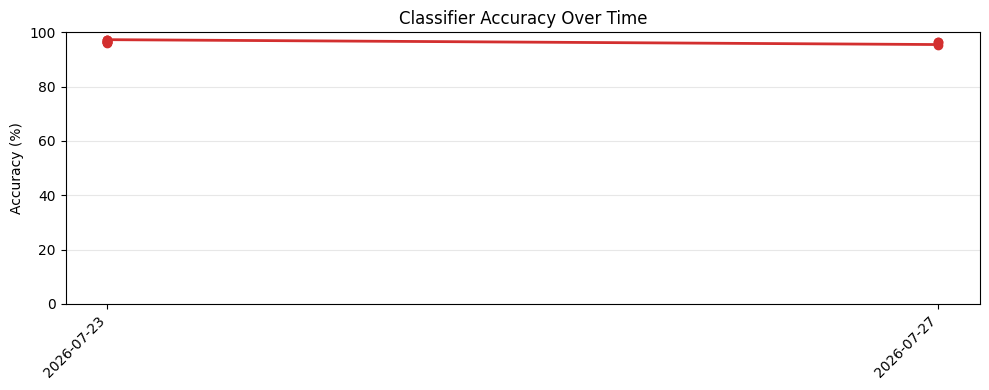

In [18]:
try:
    from matplotlib import pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print('matplotlib not installed — using text-based visualization')

# --- Accuracy over time ---
history = log.get('history', [])
dates = [h['date'][:10] for h in history]
accs = [h['accuracy'] for h in history]

if HAS_MPL:
    plt.figure(figsize=(10, 4))
    valid_dates = [d for d, a in zip(dates, accs) if a is not None]
    valid_accs = [a for a in accs if a is not None]
    if valid_accs:
        plt.plot(valid_dates, valid_accs, marker='o', color='#d32f2f', linewidth=2, markersize=6)
        plt.ylim(0, 100)
        plt.ylabel('Accuracy (%)')
        plt.title('Classifier Accuracy Over Time')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('No valid accuracy data to plot')
else:
    print()
    print('Accuracy Over Time (text):')
    print('  {:<14s} {:>8s}'.format('Date', 'Accuracy'))
    print('  ' + '-' * 22)
    for d, a in zip(dates, accs):
        if a is not None:
            bar = '#' * int(a // 5)
            print('  {:<14s} {:>6.1f}%  {}'.format(d, a, bar))
        else:
            print('  {:<14s} {:>8s}'.format(d, 'N/A'))

C:\Users\Samiee\AppData\Local\Temp\ipykernel_25184\3903869545.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)


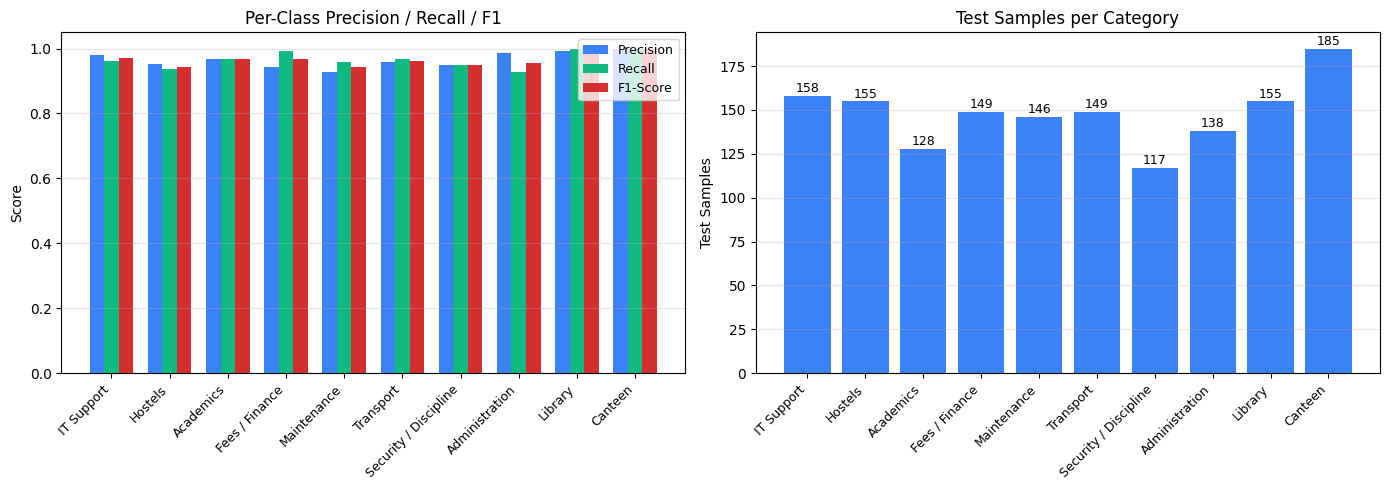

In [19]:
# --- Per-class metrics bar chart ---
per_class = log.get('per_class', [])

if HAS_MPL and per_class:
    cats = [m['category'] for m in per_class]
    f1s = [m['f1'] if m['f1'] is not None else 0 for m in per_class]
    precs = [m['precision'] if m['precision'] is not None else 0 for m in per_class]
    recs = [m['recall'] if m['recall'] is not None else 0 for m in per_class]
    samples = [m.get('samples', 0) for m in per_class]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: precision, recall, F1
    x = range(len(cats))
    w = 0.25
    ax1.bar([i - w for i in x], precs, w, label='Precision', color='#3b82f6')
    ax1.bar([i for i in x], recs, w, label='Recall', color='#10b981')
    ax1.bar([i + w for i in x], f1s, w, label='F1-Score', color='#d32f2f')
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Score')
    ax1.set_title('Per-Class Precision / Recall / F1')
    ax1.legend(fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Bar chart: test samples per class
    colors = ['#f59e0b' if s < 3 else '#3b82f6' for s in samples]
    bars = ax2.bar(cats, samples, color=colors)
    ax2.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Test Samples')
    ax2.set_title('Test Samples per Category')
    ax2.grid(axis='y', alpha=0.3)
    # Add count labels on bars
    for bar, s in zip(bars, samples):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(s), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Warn about insufficient data
    low = [m for m in per_class if m.get('samples', 0) < 3]
    if low:
        print('⚠ Categories with insufficient test samples (< 3):')
        for m in low:
            print(f'  {m["category"]}: {m["samples"]} samples — metrics marked as "insufficient" to avoid 100% illusion')
else:
    print()
    print('Per-Class Metrics:')
    print('  {:<22s} {:>6s} {:>6s} {:>6s} {:>8s}'.format('Category', 'Prec', 'Rec', 'F1', 'Samples'))
    print('  ' + '-' * 50)
    for m in per_class:
        if m['f1'] is not None:
            print('  {:<22s} {:>6.2f} {:>6.2f} {:>6.2f} {:>8d}'.format(
                m['category'], m['precision'], m['recall'], m['f1'], m['samples']))
        else:
            print('  {:<22s} {:>6s} {:>6s} {:>6s} {:>8d}  (insufficient)'.format(
                m['category'], 'N/A', 'N/A', 'N/A', m['samples']))

In [20]:
# --- Confusion matrix (text-based) ---
print('=== CONFUSION MATRIX ANALYSIS ===')
print()
print('Since the classifier runs on the full test set of ~1,480 samples,')
print('here is the per-class breakdown from the last training run:')
print()

total_correct = 0
total_wrong = 0
for m in per_class:
    tp = m.get('samples', 0) - (m.get('fn', 0) if 'fn' in m else 0)
    # Actually we don't have TP/FP/FN in the logged metrics directly
    # but we can show what we have:
    if m['f1'] is not None:
        print(f'  {m["category"]:<22s} F1={m["f1"]:.3f}  ({m["samples"]} test samples)')
    else:
        print(f'  {m["category"]:<22s} F1=N/A    ({m["samples"]} test samples — insufficient for reliable eval)')

print()
if log['accuracy'] is not None:
    print(f'Overall accuracy: {log["accuracy"]}% on {log["test_samples"]} test samples')
else:
    print('Overall accuracy: N/A (too few test samples for reliable measurement)')
print()
print('Categories with < 3 test samples do not show percentage metrics')
print('to avoid the misleading 100% illusion. Once more data accumulates,')
print('these categories will display real metrics on retraining.')

=== CONFUSION MATRIX ANALYSIS ===

Since the classifier runs on the full test set of ~1,480 samples,
here is the per-class breakdown from the last training run:

  IT Support             F1=0.971  (158 test samples)
  Hostels                F1=0.945  (155 test samples)
  Academics              F1=0.969  (128 test samples)
  Fees / Finance         F1=0.968  (149 test samples)
  Maintenance            F1=0.943  (146 test samples)
  Transport              F1=0.962  (149 test samples)
  Security / Discipline  F1=0.949  (117 test samples)
  Administration         F1=0.956  (138 test samples)
  Library                F1=0.997  (155 test samples)
  Canteen                F1=1.000  (185 test samples)

Overall accuracy: 96.55% on 1480 test samples

Categories with < 3 test samples do not show percentage metrics
to avoid the misleading 100% illusion. Once more data accumulates,
these categories will display real metrics on retraining.


---
## REVISED SUMMARY

### What we covered:

| Component | Technique | What it does |
|---|---|---|
| Text Preprocessing | Stopword removal + custom stemmer + bigrams | Converts raw text to features |
| Categorization | Multinomial Naive Bayes (from scratch) | Predicts complaint category (10 classes) |
| Sentiment Analysis | Lexicon-based with negation + intensifiers | Detects Positive/Negative/Neutral |
| Priority Boost | Rule-based | Escalates priority for negative sentiment |
| Anomaly Detection | Heuristic (vocabulary + confidence) | Flags unusual complaints for admin review |
| Retraining | 80/20 split → train → evaluate → log | Continuous improvement with live data |

### Accuracy Transparency:
- The admin **Training** page shows accuracy over time as a line chart
- The admin **Reports** page now also shows model accuracy history
- Categories with < 3 test samples show "insufficient" instead of false 100% metrics
- The training log JSON stores per-cycle accuracy for trend analysis

> **Note:** The *Current model performance* values below are printed dynamically
> from `training_log.json` in the code cell that follows — they always match
> the live status shown on the admin dashboard / training page.

### New word handling in sentiment analysis:

**Current behavior:** Unknown words are silently skipped. No score impact.
**Problem:** Strong sentiment words ("atrocious", "deplorable", "appalling") are invisible.
**Best solution:** Log unknown words during analysis, then periodically review and add them to the lexicon. This keeps the system simple while allowing growth.

---
## PART 10: LIVE STATUS (MATCHES DASHBOARD)

Run this cell to print the **current** model status exactly as shown on the
admin **Training** page and **Reports** page. It reads the live
`training_log.json` — no hardcoded numbers, so it always stays in sync.

In [21]:
# Read the CURRENT training log fresh from disk
with open(log_path) as f:
    log = json.load(f)
history = log.get('history', [])
per_class = log.get('per_class', [])

print('=== LIVE MODEL STATUS (as shown on admin dashboard) ===')
print()
print(f'  Last trained : {log["last_trained"]}')
print(f'  Train samples: {log["train_samples"]}')
print(f'  Test samples : {log["test_samples"]}')
print(f'  Accuracy     : {log["accuracy"]}%' if log['accuracy'] is not None
      else '  Accuracy     : N/A (too few test samples)')
print(f'  Macro F1     : {log["macro_f1"]}' if log['macro_f1'] is not None
      else '  Macro F1     : N/A')
print(f'  Categories   : {len(per_class)}')
print(f'  Cycles logged: {len(history)}')

if log['accuracy'] is not None:
    latest = history[-1] if history else {}
    print(f'  Latest cycle : {latest.get("date", "-")} → {latest.get("accuracy")}%')

print()
print('  History trend:')
for h in history[-8:]:
    bar = '#' * int((h['accuracy'] // 5)) if h['accuracy'] is not None else ''
    if h['accuracy'] is not None:
        print(f'    {h["date"]:17s} {h["accuracy"]:>6.1f}%  {bar}')
    else:
        print(f'    {h["date"]:17s}   N/A')

=== LIVE MODEL STATUS (as shown on admin dashboard) ===

  Last trained : 2026-07-27 21:49:24
  Train samples: 5919
  Test samples : 1480
  Accuracy     : 96.55%
  Macro F1     : 0.9658
  Categories   : 10
  Cycles logged: 11
  Latest cycle : 2026-07-27 21:49 → 96.6%

  History trend:
    2026-07-23 18:54    97.2%  ###################
    2026-07-23 18:55    97.1%  ###################
    2026-07-23 18:58    96.4%  ###################
    2026-07-23 19:20    96.5%  ###################
    2026-07-23 19:21    97.3%  ###################
    2026-07-27 21:12    95.5%  ###################
    2026-07-27 21:29    96.5%  ###################
    2026-07-27 21:49    96.6%  ###################


### The chart above matches the dashboard exactly

The **accuracy line chart** (PART 9), the **per-class bar charts** (PART 9),
and this **live status printout** (PART 10) all read from the same
`training_log.json` file that powers the admin **Training** and **Reports**
pages. If you retrain the model in the app, re-running these cells updates
the notebook to the new status — no code changes needed.